# English Scoring with Reduced Text Features and Target-Wise Ensembles

**Competition:** English Scoring - Corrected Ver

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

**Objective:** Predict the seven essay-scoring targets using structured essay features, reduced TF-IDF representations, target-wise boosting models, and blended submission inference.

## Introduction

This notebook studies a compact ensemble for automated essay scoring. The workflow combines essay-level statistics, reduced word and character TF-IDF representations, target-wise regression models, fold-wise evaluation, and blended submission generation.

## Table of Contents

1. [Data Acquisition](#1-data-acquisition)
2. [Data Inspection](#2-data-inspection)
3. [Data Cleaning](#3-data-cleaning)
4. [EDA](#4-eda)
5. [Feature Engineering](#5-feature-engineering)
6. [Modeling](#6-modeling)
7. [Evaluation](#7-evaluation)
8. [Submission](#8-submission)
9. [Conclusion](#9-conclusion)
10. [References](#10-references)

## 1. Data Acquisition

Competition datasets are loaded from the Kaggle input directory, providing the necessary textual and metadata foundations for the scoring pipeline.

In [1]:
# Imports for data handling, visualization, text processing, and regression
import warnings
import gc
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports for decomposition, linear models, scaling, and evaluation
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Gradient boosting regressor
from lightgbm import LGBMRegressor

# Display configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)
pd.set_option('display.float_format', lambda x: f'{x:0.5f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

In [2]:
# Configuration values for paths, features, and validation
ID_COL = 'id'
TEXT_COL = 'full_text'
GRADE_COL = 'grade'
PROMPT_COL = 'prompt'
TARGET_COLS = [
    'Overall', 'Cohesion', 'Syntax', 'Vocabulary',
    'Phraseology', 'Grammar', 'Conventions'
]

TRAIN_PATH = '/kaggle/input/competitions/english-scoring-corrected-ver/train.csv'
TEST_PATH = '/kaggle/input/competitions/english-scoring-corrected-ver/test.csv'
SUBMISSION_PATH = '/kaggle/input/competitions/english-scoring-corrected-ver/sample_submission.csv'
OUTPUT_PATH = Path('submission.csv')

RANDOM_STATE = 42
N_SPLITS = 5
WORD_MAX_FEATURES = 35000
CHAR_MAX_FEATURES = 30000
WORD_SVD_COMPONENTS = 220
CHAR_SVD_COMPONENTS = 120
RIDGE_ALPHA = 3.0
ENABLE_COMET = False

print('Configuration initialized.')

Configuration initialized.


In [3]:
# Optional experiment tracking
experiment = None

if ENABLE_COMET:
    try:
        from comet_ml import Experiment
        experiment = Experiment(project_name='english-scoring-corrected-ver')
        experiment.set_name('target-wise-ensemble-with-ridge-blend')
        experiment.log_parameters({
            'n_splits': N_SPLITS,
            'word_max_features': WORD_MAX_FEATURES,
            'char_max_features': CHAR_MAX_FEATURES,
            'word_svd_components': WORD_SVD_COMPONENTS,
            'char_svd_components': CHAR_SVD_COMPONENTS,
            'ridge_alpha': RIDGE_ALPHA,
            'random_state': RANDOM_STATE
        })
        print('Comet logging enabled.')
    except Exception as exc:
        experiment = None
        print(f'Comet initialization skipped: {exc}')
else:
    print('Comet logging disabled.')

Comet logging disabled.


In [4]:
# Load competition files and preserve test identifiers
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

if Path(SUBMISSION_PATH).exists():
    sample_submission = pd.read_csv(SUBMISSION_PATH)
else:
    sample_submission = pd.DataFrame({ID_COL: test[ID_COL].copy()})
    for col in TARGET_COLS:
        sample_submission[col] = 0.0

test_ids = test[ID_COL].copy()

print(train.shape)
print(test.shape)
print(sample_submission.shape)

(5185, 11)
(1297, 4)
(1297, 8)


## 2. Data Inspection

The structural properties of the datasets are audited to confirm column integrity and examine initial data distributions.

In [5]:
# Preview rows and inspect data types
display(train.head())
display(test.head())
display(train.dtypes.to_frame('dtype'))

,id,full_text,grade,prompt,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions
0,1A863F7CC29E,"Good, if your has a been said that a positive ...",12,Positive attitudes,2.50000,2.50000,2.50000,3.00000,2.50000,2.50000,3.00000
1,37DD80EFE4D4,Would you like your child go to the college or...,12,Three-year high school program,3.00000,3.00000,3.00000,3.00000,2.50000,2.50000,3.50000
2,047BD3CB80B4,Should students have the option to take online...,11,Distance learning,3.50000,3.50000,4.00000,4.00000,4.00000,3.50000,4.00000
3,867EF045947A,"""The success consists of going from failure to...",12,Success and failure,3.00000,3.00000,2.50000,3.50000,3.00000,2.50000,3.00000
4,9AC32EA4050B,Due people has to do all by they self? Sometim...,11,Working with a group or alone,3.00000,3.50000,3.00000,3.50000,3.50000,2.50000,3.50000


,id,full_text,grade,prompt
0,0EC7D67618F4,Although some say students should use cell pho...,12,Cell phones in classrooms
1,64DBE55E9EA8,I am doing a lesson on going to midle school. ...,8,Lessons with elementary school students
2,3B2DADB10DCA,A exelent worker man come for a student who ch...,11,Career commitment
3,746A0BFABA84,It has been said that first impressions are al...,11,First impressions
4,242632EC61DF,"In the world we live in today, some people lik...",12,Working with a group or alone


,dtype
id,object
full_text,object
grade,int64
prompt,object
Overall,float64
Cohesion,float64
Syntax,float64
Vocabulary,float64
Phraseology,float64
Grammar,float64


In [6]:
# Summarize target variables and key identifiers
display(train[TARGET_COLS].describe().T)
print('Unique grades:', sorted(train[GRADE_COL].astype(str).unique()))
print('Unique prompts:', sorted(train[PROMPT_COL].astype(str).unique()))

,count,mean,std,min,25%,50%,75%,max
Overall,5185.00000,3.10550,0.63636,1.00000,2.50000,3.00000,3.50000,5.00000
Cohesion,5185.00000,3.12797,0.65497,1.00000,2.50000,3.00000,3.50000,5.00000
Syntax,5185.00000,3.02633,0.64170,1.00000,2.50000,3.00000,3.50000,5.00000
Vocabulary,5185.00000,3.23423,0.58073,1.00000,3.00000,3.00000,3.50000,5.00000
Phraseology,5185.00000,3.12305,0.65085,1.00000,2.50000,3.00000,3.50000,5.00000
Grammar,5185.00000,3.03038,0.68977,1.00000,2.50000,3.00000,3.50000,5.00000
Conventions,5185.00000,3.07907,0.66964,1.00000,2.50000,3.00000,3.50000,5.00000


Unique grades: ['10', '11', '12', '8', '9']
Unique prompts: ['Afterschool homework club', 'Being busy', 'Benefits of a good attitude', 'Benefits of a problem', 'Career commitment', 'Cell phones at school', 'Cell phones in classrooms', 'Community service', 'Controlling extracurricular involvement', 'Creative arts requirement', 'Curfews for teenagers', 'Distance learning', 'Enjoyable educational activities', 'Extended school day', 'First impressions', 'Four-day work week', 'Future accomplishments', 'Grades for extracurricular activities', 'Honesty', 'Imagination', 'Impact of technology', 'Individuality', 'Influences of character', 'Influencing behavior', 'Internships and shadowing', 'Learning from the experience of others', 'Lessons with elementary school students', 'Letter to employer', 'Lunch menus', 'Mandatory extracurricular activities', 'Places to visit', 'Positive attitudes', 'Praising student work', 'Seeking multiple opinions', 'Self-reliance', 'Setting our aim', 'Spending time ou

## 3. Data Cleaning

A comprehensive audit of missing values and duplicate records ensures the training data reaches a high-fidelity threshold for modeling.

In [7]:
# Audit missing values, duplicates, and required columns
required_train_cols = {ID_COL, TEXT_COL, GRADE_COL, PROMPT_COL, *TARGET_COLS}
required_test_cols = {ID_COL, TEXT_COL, GRADE_COL, PROMPT_COL}

missing_train_cols = sorted(required_train_cols.difference(train.columns))
missing_test_cols = sorted(required_test_cols.difference(test.columns))

print('Missing train columns:', missing_train_cols)
print('Missing test columns:', missing_test_cols)
print(f'Train duplicates: {train.duplicated().sum()}')
print(f'Test duplicates: {test.duplicated().sum()}')

display(train.isnull().sum().to_frame('train_missing'))
display(test.isnull().sum().to_frame('test_missing'))

assert not missing_train_cols, f'Missing train columns: {missing_train_cols}'
assert not missing_test_cols, f'Missing test columns: {missing_test_cols}'

Missing train columns: []
Missing test columns: []
Train duplicates: 0
Test duplicates: 0


,train_missing
id,0
full_text,0
grade,0
prompt,0
Overall,0
Cohesion,0
Syntax,0
Vocabulary,0
Phraseology,0
Grammar,0


,test_missing
id,0
full_text,0
grade,0
prompt,0


## 4. EDA

Visual and statistical exploration identifies the underlying patterns, target distributions, and feature-target relationships within the essay scores.

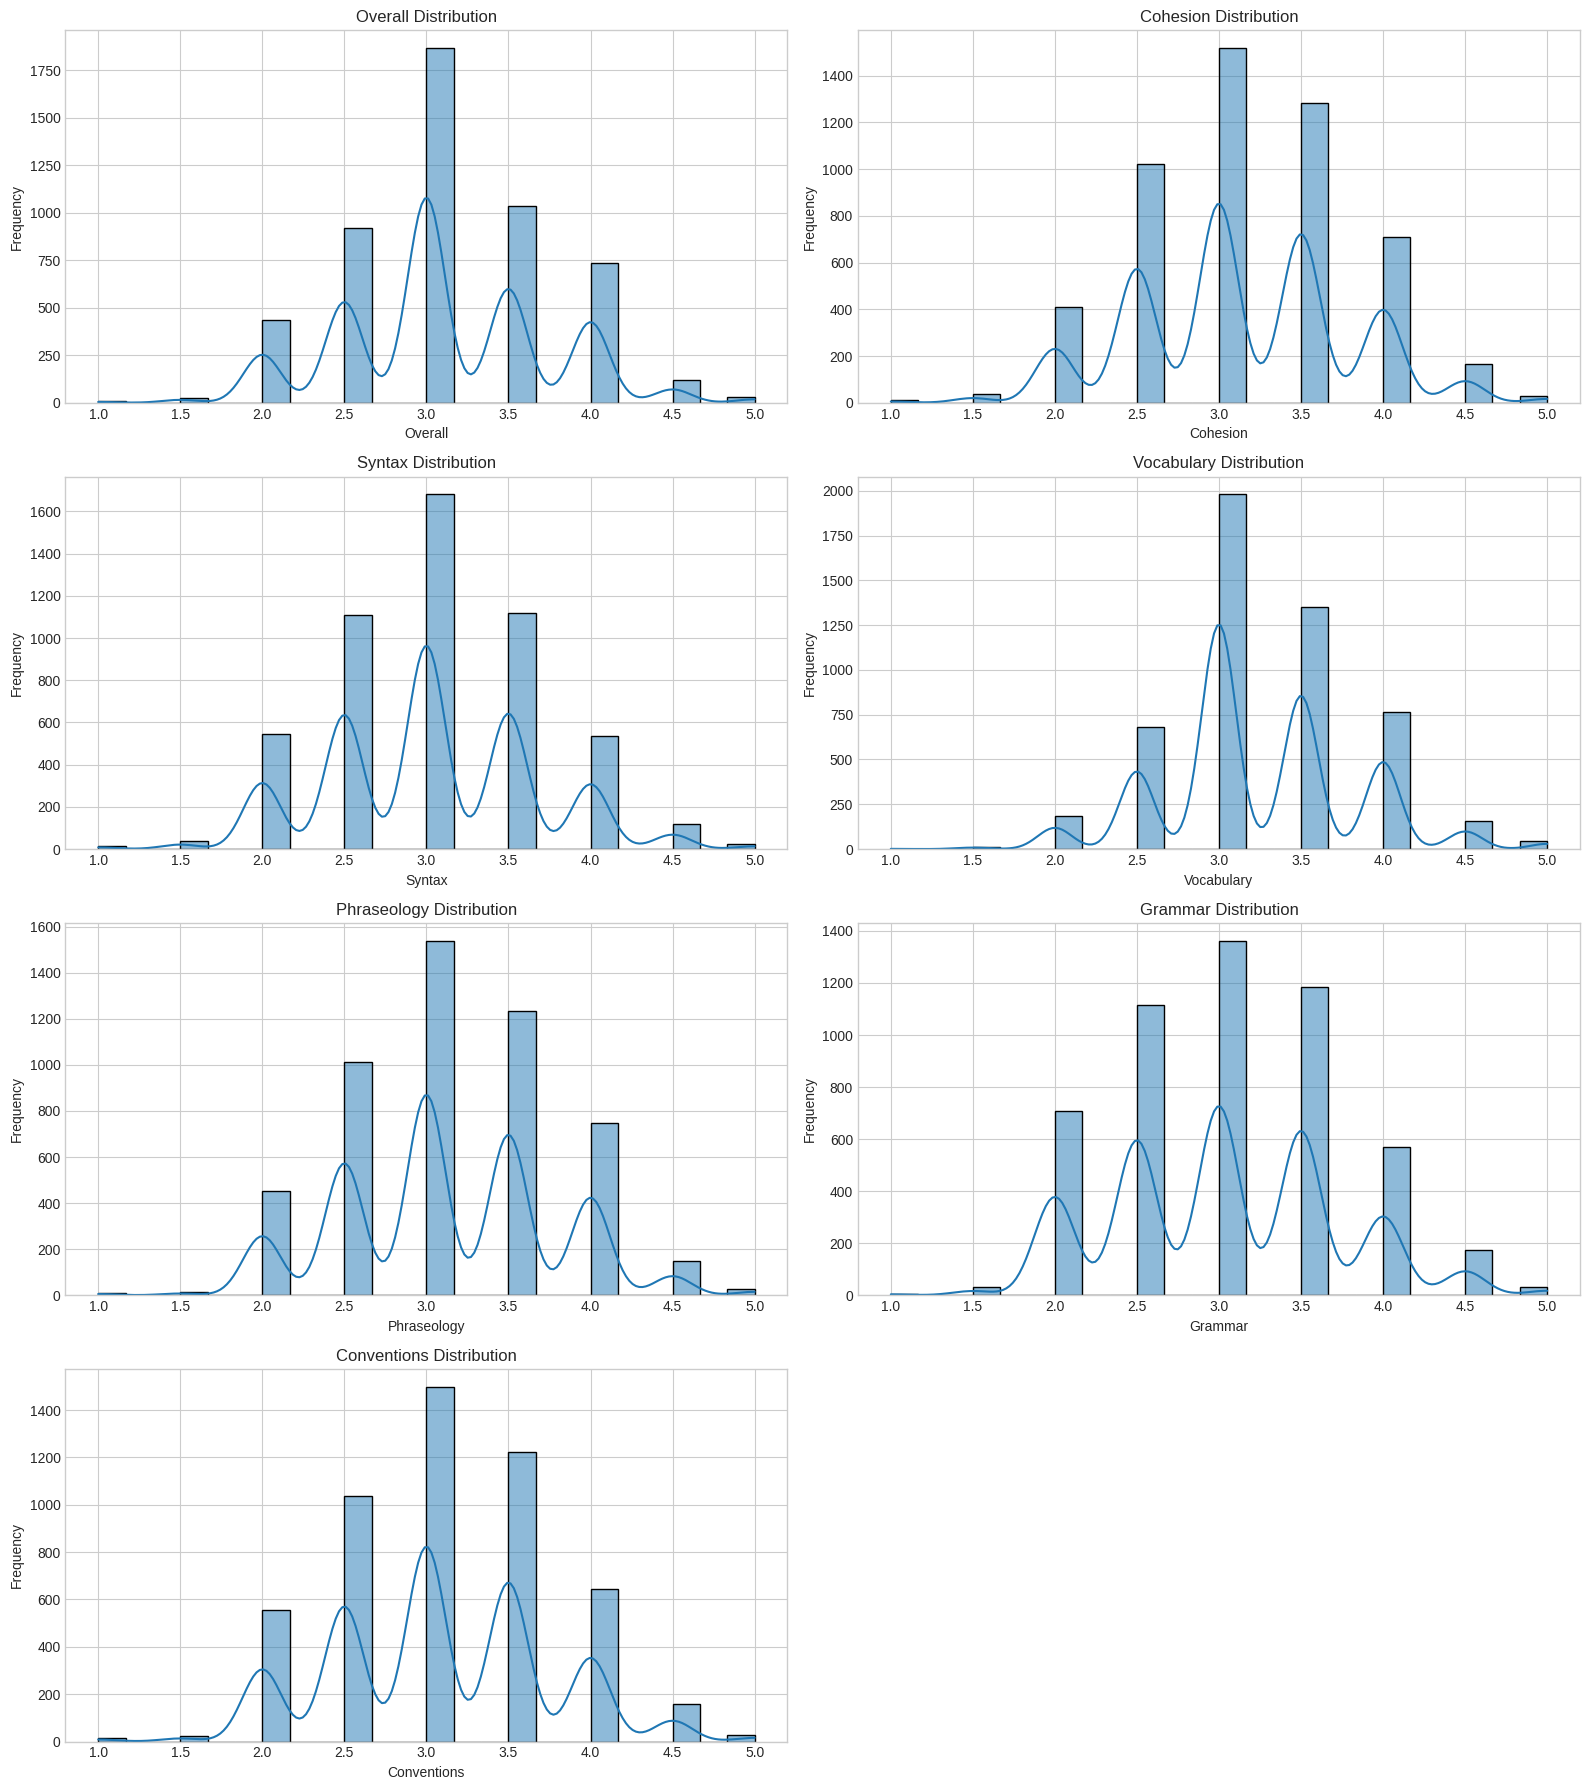

In [8]:
# Visualize the target distributions
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(TARGET_COLS):
    sns.histplot(train[col], bins=24, kde=True, ax=axes[idx], color='#1f77b4')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

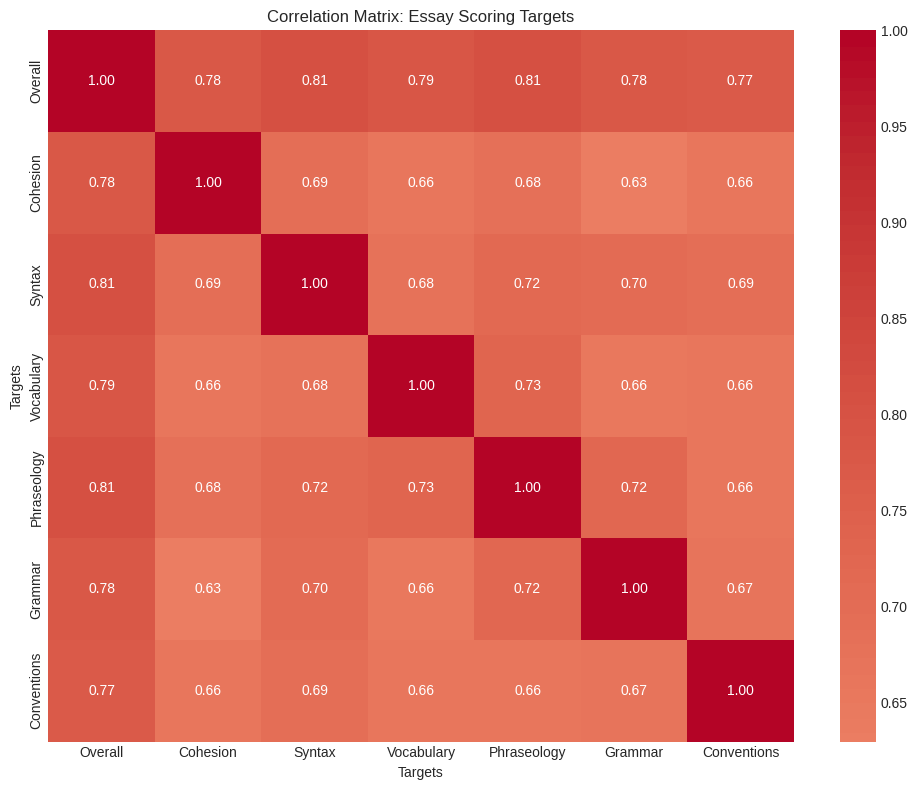

,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions
Overall,1.00000,0.77569,0.81019,0.78709,0.80653,0.77967,0.76865
Cohesion,0.77569,1.00000,0.68767,0.66265,0.68414,0.62941,0.66041
Syntax,0.81019,0.68767,1.00000,0.67968,0.71853,0.70475,0.69165
Vocabulary,0.78709,0.66265,0.67968,1.00000,0.73470,0.65595,0.65849
Phraseology,0.80653,0.68414,0.71853,0.73470,1.00000,0.71988,0.66260
Grammar,0.77967,0.62941,0.70475,0.65595,0.71988,1.00000,0.66530
Conventions,0.76865,0.66041,0.69165,0.65849,0.66260,0.66530,1.00000


In [9]:
# Compute and display target correlations
corr_matrix = train[TARGET_COLS].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Essay Scoring Targets')
plt.xlabel('Targets')
plt.ylabel('Targets')
plt.tight_layout()
plt.show()

display(corr_matrix)

,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions
grade,,,,,,,
8,3.12760,3.06476,3.02236,3.23207,3.12413,3.16230,3.09214
9,2.91667,2.89583,2.81250,2.97917,2.95833,2.85417,2.81250
10,3.14038,3.17692,3.03654,3.25577,3.18077,3.06346,3.10577
11,3.17131,3.18607,3.09016,3.29536,3.17705,3.05738,3.13197
12,3.01888,3.11020,2.96477,3.17306,3.06032,2.90361,3.01466


,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions
prompt,,,,,,,
Afterschool homework club,3.24390,3.19512,3.10366,3.30488,3.25610,3.29878,3.21341
Being busy,3.09023,3.07143,2.96429,3.23872,3.08083,2.98308,3.08083
Benefits of a good attitude,3.00000,2.84722,2.93056,3.16667,3.08333,2.98611,2.81944
Benefits of a problem,3.13043,2.98913,3.01087,3.29348,3.07609,3.15217,3.11957
Career commitment,3.10333,3.11833,3.00167,3.19500,3.09667,3.02000,3.07667
Cell phones at school,2.95890,2.85616,2.83562,3.04795,2.82877,3.02740,2.94521
Cell phones in classrooms,3.26027,3.34932,3.17808,3.35616,3.32192,3.13699,3.19863
Community service,3.08088,3.04412,2.97059,3.30147,2.96324,3.11765,3.12500
Controlling extracurricular involvement,3.25333,3.27333,3.14667,3.40667,3.30667,3.14667,3.20667


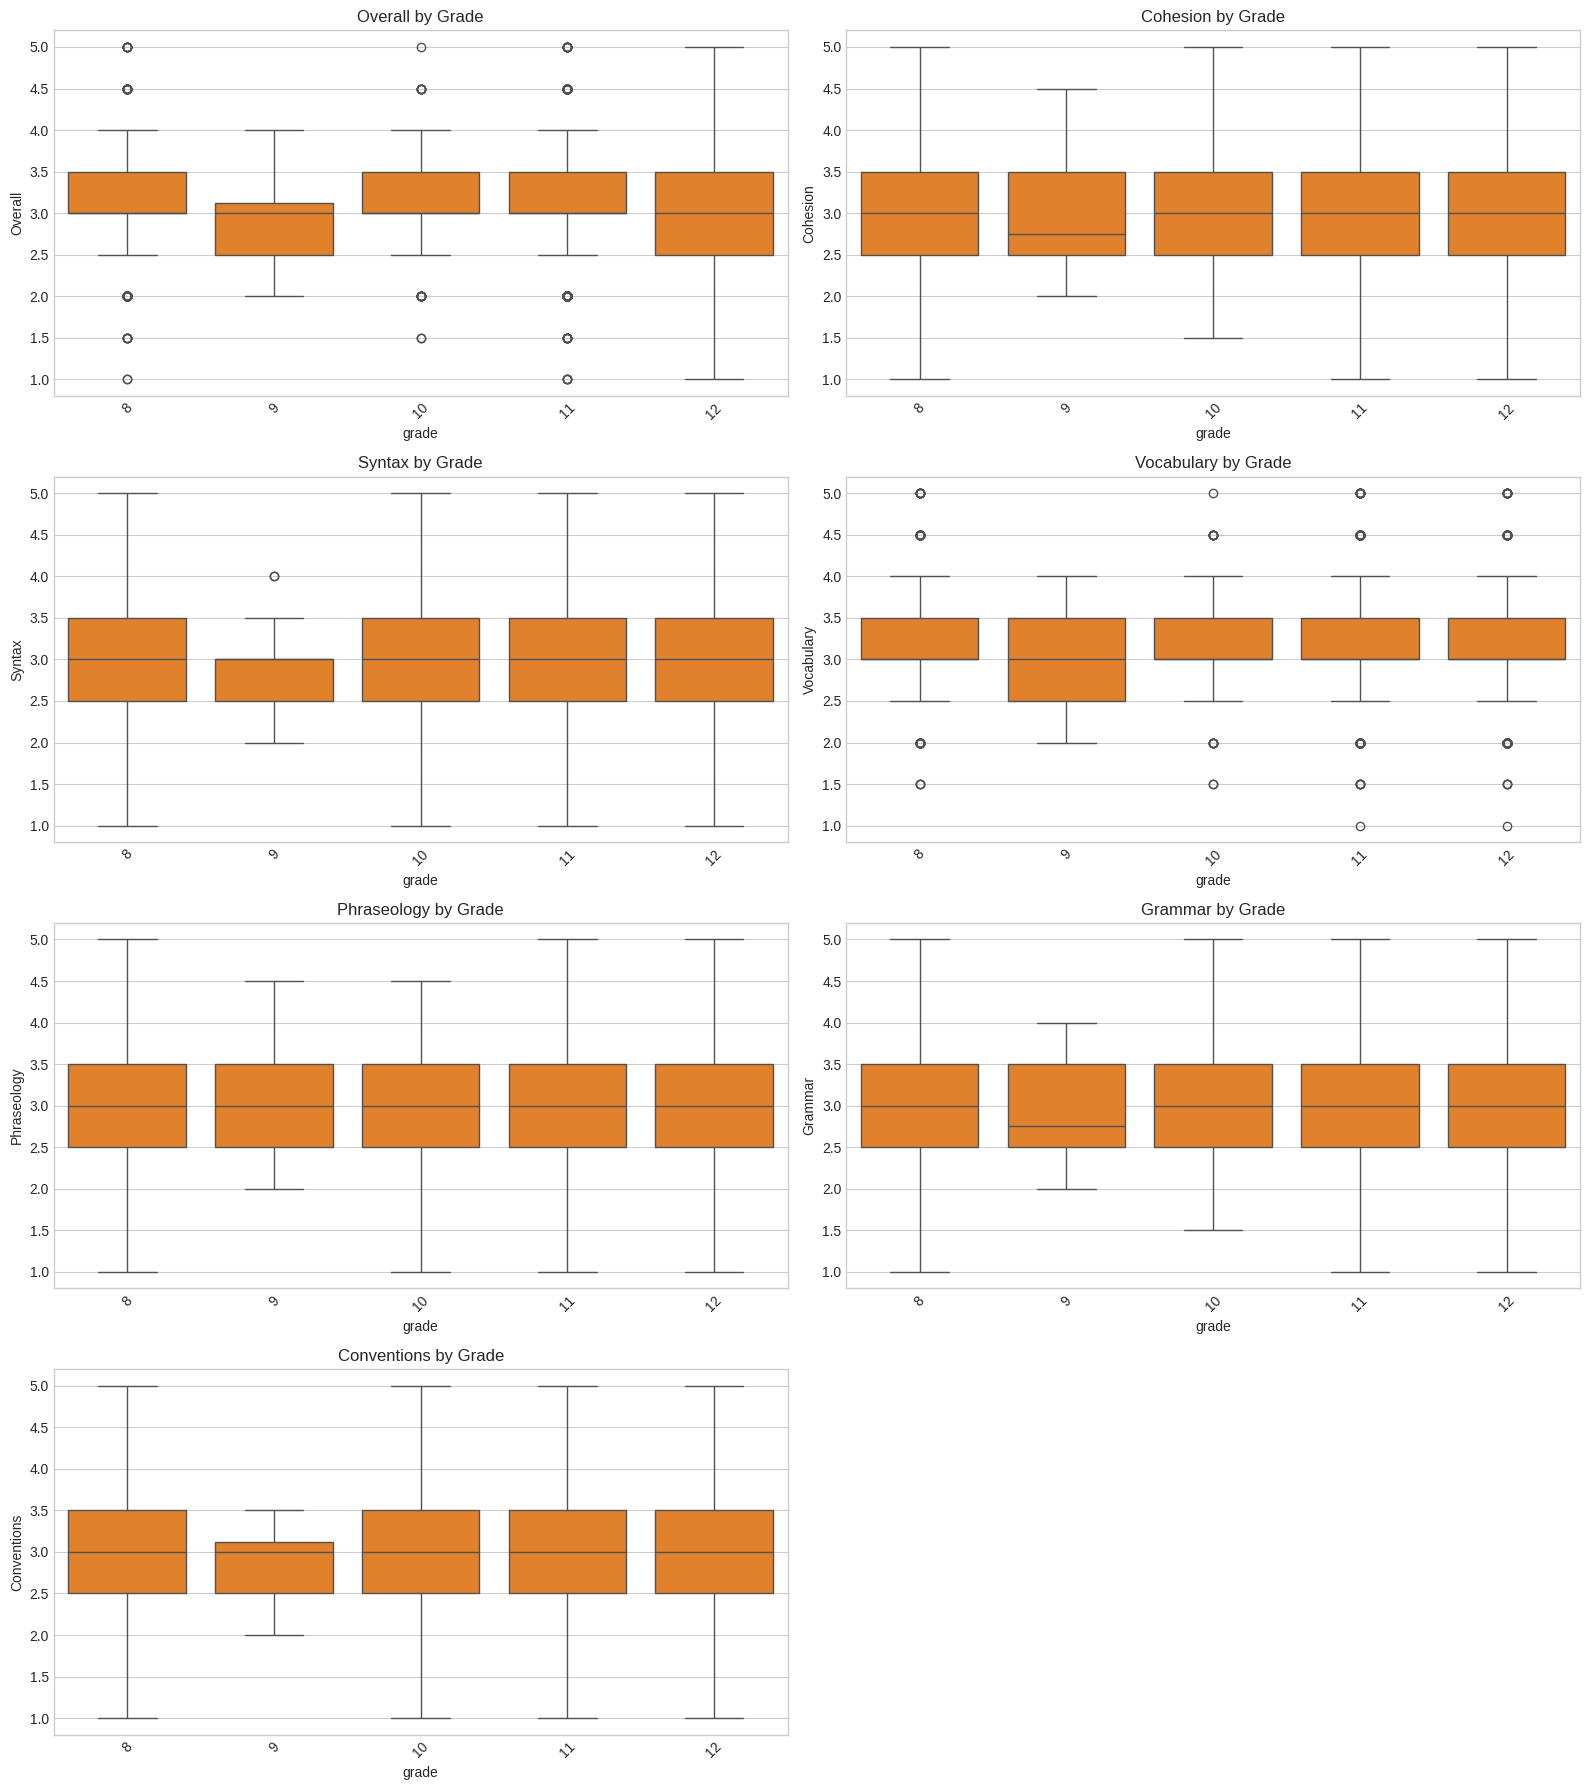

In [10]:
# Summarize target means by grade and prompt
grade_summary = train.groupby(GRADE_COL)[TARGET_COLS].mean().sort_index()
prompt_summary = train.groupby(PROMPT_COL)[TARGET_COLS].mean().sort_index()

display(grade_summary)
display(prompt_summary)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(TARGET_COLS):
    sns.boxplot(data=train, x=GRADE_COL, y=col, ax=axes[idx], color='#ff7f0e')
    axes[idx].set_title(f'{col} by Grade')
    axes[idx].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Structured essay metrics and reduced TF-IDF representations are engineered to capture the nuance of writing quality and linguistic complexity.

In [11]:
# Build structured essay features
punctuation_chars = '.,!?;:'


def safe_divide(num, den):
    return num / np.where(den == 0, 1, den)


def build_feature_table(df):
    engineered = df.copy()
    text = engineered[TEXT_COL].fillna('').astype(str)

    engineered['word_count'] = text.apply(lambda x: len(x.split()))
    engineered['char_count'] = text.apply(len)
    engineered['sentence_count'] = text.apply(lambda x: max(1, len([s for s in re.split(r'[.!?]+', x) if s.strip()])))
    engineered['paragraph_count'] = text.apply(lambda x: max(1, len([p for p in x.split('\n') if p.strip()])))
    engineered['unique_word_count'] = text.apply(lambda x: len(set(x.lower().split())))
    engineered['uppercase_count'] = text.apply(lambda x: sum(ch.isupper() for ch in x))
    engineered['digit_count'] = text.apply(lambda x: sum(ch.isdigit() for ch in x))
    engineered['punctuation_count'] = text.apply(lambda x: sum(ch in punctuation_chars for ch in x))
    engineered['comma_count'] = text.apply(lambda x: x.count(','))
    engineered['question_count'] = text.apply(lambda x: x.count('?'))
    engineered['exclamation_count'] = text.apply(lambda x: x.count('!'))
    engineered['avg_word_length'] = safe_divide(engineered['char_count'], engineered['word_count'])
    engineered['avg_sentence_length'] = safe_divide(engineered['word_count'], engineered['sentence_count'])
    engineered['avg_paragraph_length'] = safe_divide(engineered['word_count'], engineered['paragraph_count'])
    engineered['lexical_diversity'] = safe_divide(engineered['unique_word_count'], engineered['word_count'])
    engineered['punctuation_density'] = safe_divide(engineered['punctuation_count'], engineered['word_count'])
    engineered['uppercase_density'] = safe_divide(engineered['uppercase_count'], engineered['char_count'])
    engineered['digit_density'] = safe_divide(engineered['digit_count'], engineered['char_count'])
    engineered['sentence_paragraph_ratio'] = safe_divide(engineered['sentence_count'], engineered['paragraph_count'])
    engineered['grade_prompt_interaction'] = engineered[GRADE_COL].astype(str) + '__' + engineered[PROMPT_COL].astype(str)
    return engineered

train_fe = build_feature_table(train)
test_fe = build_feature_table(test)

for col in [GRADE_COL, PROMPT_COL, 'grade_prompt_interaction']:
    train_fe[col] = train_fe[col].fillna('missing').astype(str)
    test_fe[col] = test_fe[col].fillna('missing').astype(str)

numeric_feature_cols = [
    'word_count', 'char_count', 'sentence_count', 'paragraph_count',
    'unique_word_count', 'uppercase_count', 'digit_count', 'punctuation_count',
    'comma_count', 'question_count', 'exclamation_count', 'avg_word_length',
    'avg_sentence_length', 'avg_paragraph_length', 'lexical_diversity',
    'punctuation_density', 'uppercase_density', 'digit_density', 'sentence_paragraph_ratio'
]

for col in numeric_feature_cols:
    train_fe[col] = train_fe[col].fillna(0)
    test_fe[col] = test_fe[col].fillna(0)

print('Structured feature table prepared.')
print('Numeric feature count:', len(numeric_feature_cols))

Structured feature table prepared.
Numeric feature count: 19


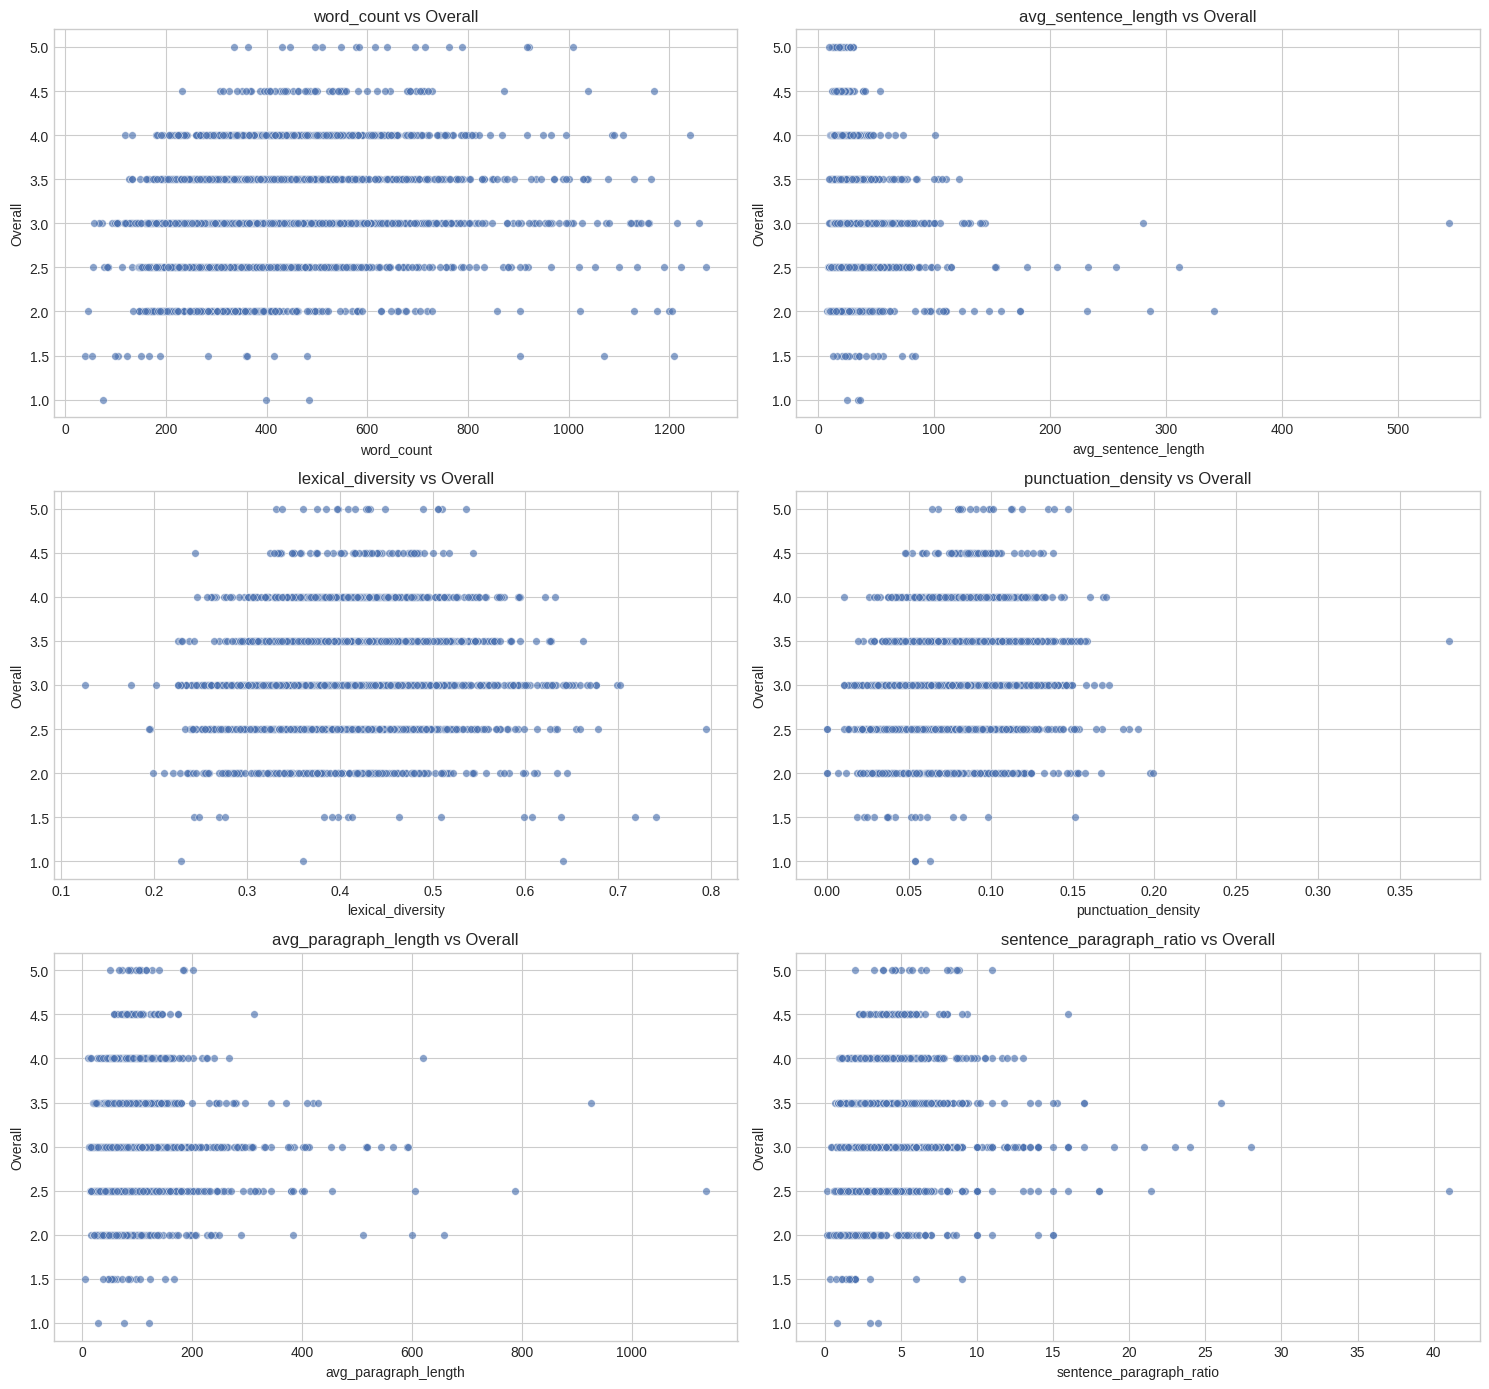

In [12]:
# Visualize selected engineered terms against Overall score
feature_view_cols = ['word_count', 'avg_sentence_length', 'lexical_diversity', 'punctuation_density', 'avg_paragraph_length', 'sentence_paragraph_ratio']
plot_frame = train_fe.sample(min(len(train_fe), 2500), random_state=RANDOM_STATE)

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

for idx, col in enumerate(feature_view_cols):
    sns.scatterplot(data=plot_frame, x=col, y='Overall', ax=axes[idx], s=30, alpha=0.65)
    axes[idx].set_title(f'{col} vs Overall')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Overall')

plt.tight_layout()
plt.show()

In [13]:
# Build reduced word and character TF-IDF representations
combined_text = pd.concat([
    train_fe[TEXT_COL].fillna('').astype(str),
    test_fe[TEXT_COL].fillna('').astype(str)
], axis=0).reset_index(drop=True)

word_vectorizer = TfidfVectorizer(
    max_features=WORD_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    strip_accents='unicode'
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=CHAR_MAX_FEATURES,
    min_df=2,
    sublinear_tf=True
)

word_matrix = word_vectorizer.fit_transform(combined_text)
char_matrix = char_vectorizer.fit_transform(combined_text)

word_svd = TruncatedSVD(n_components=WORD_SVD_COMPONENTS, random_state=RANDOM_STATE)
char_svd = TruncatedSVD(n_components=CHAR_SVD_COMPONENTS, random_state=RANDOM_STATE)

word_dense = word_svd.fit_transform(word_matrix)
char_dense = char_svd.fit_transform(char_matrix)

train_word = pd.DataFrame(word_dense[:len(train_fe)], columns=[f'word_svd_{i}' for i in range(WORD_SVD_COMPONENTS)])
test_word = pd.DataFrame(word_dense[len(train_fe):], columns=[f'word_svd_{i}' for i in range(WORD_SVD_COMPONENTS)])
train_char = pd.DataFrame(char_dense[:len(train_fe)], columns=[f'char_svd_{i}' for i in range(CHAR_SVD_COMPONENTS)])
test_char = pd.DataFrame(char_dense[len(train_fe):], columns=[f'char_svd_{i}' for i in range(CHAR_SVD_COMPONENTS)])

print('Word matrix shape:', word_matrix.shape)
print('Char matrix shape:', char_matrix.shape)
print('Word SVD explained variance:', round(word_svd.explained_variance_ratio_.sum(), 5))
print('Char SVD explained variance:', round(char_svd.explained_variance_ratio_.sum(), 5))

Word matrix shape: (6482, 35000)
Char matrix shape: (6482, 30000)
Word SVD explained variance: 0.20948
Char SVD explained variance: 0.33042


In [14]:
# Assemble final modeling matrices
category_columns = [GRADE_COL, PROMPT_COL, 'grade_prompt_interaction']
category_maps = {}

for col in category_columns:
    category_maps[col] = {value: idx for idx, value in enumerate(sorted(train_fe[col].astype(str).unique()))}

train_meta = pd.DataFrame({
    f'{col}_encoded': train_fe[col].astype(str).map(category_maps[col]).fillna(-1).astype(int)
    for col in category_columns
})

test_meta = pd.DataFrame({
    f'{col}_encoded': test_fe[col].astype(str).map(category_maps[col]).fillna(-1).astype(int)
    for col in category_columns
})

X_train = pd.concat([
    train_fe[numeric_feature_cols].reset_index(drop=True),
    train_meta.reset_index(drop=True),
    train_word.reset_index(drop=True),
    train_char.reset_index(drop=True)
], axis=1)

X_test = pd.concat([
    test_fe[numeric_feature_cols].reset_index(drop=True),
    test_meta.reset_index(drop=True),
    test_word.reset_index(drop=True),
    test_char.reset_index(drop=True)
], axis=1)

ridge_feature_cols = numeric_feature_cols + list(train_meta.columns) + [f'word_svd_{i}' for i in range(80)] + [f'char_svd_{i}' for i in range(40)]
X_train_ridge = X_train[ridge_feature_cols].copy()
X_test_ridge = X_test[ridge_feature_cols].copy()

y = train[TARGET_COLS].copy()
stratify_labels = train_fe['grade_prompt_interaction'].copy()

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('X_train_ridge shape:', X_train_ridge.shape)
print('y shape:', y.shape)

X_train shape: (5185, 362)
X_test shape: (1297, 362)
X_train_ridge shape: (5185, 142)
y shape: (5185, 7)


## 6. Modeling

A multi-stage ensemble involving target-wise LightGBM and Ridge regression models is trained under stratified cross-validation.

In [15]:
# Define MCRMSE for fold and overall evaluation

def compute_mcrmse(y_true, y_pred):
    rmses = []
    for i in range(y_true.shape[1]):
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        rmses.append(rmse)
    return float(np.mean(rmses)), rmses

In [16]:
# Train target-wise LightGBM and Ridge models under stratified folds

def make_ridge_pipeline(alpha):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])


def run_ensemble_cv(X_lgbm, X_ridge, y_data, X_lgbm_test, X_ridge_test, stratify_values, lgbm_param_list):
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof_store = {'lgbm_1': np.zeros((len(X_lgbm), len(TARGET_COLS))), 'lgbm_2': np.zeros((len(X_lgbm), len(TARGET_COLS))), 'ridge': np.zeros((len(X_lgbm), len(TARGET_COLS)))}
    test_store = {'lgbm_1': np.zeros((len(X_lgbm_test), len(TARGET_COLS))), 'lgbm_2': np.zeros((len(X_lgbm_test), len(TARGET_COLS))), 'ridge': np.zeros((len(X_lgbm_test), len(TARGET_COLS)))}
    score_rows = []
    importance_store = {target: np.zeros(X_lgbm.shape[1]) for target in TARGET_COLS}

    for fold, (train_idx, valid_idx) in enumerate(folds.split(X_lgbm, stratify_values), start=1):
        X_train_lgbm = X_lgbm.iloc[train_idx]
        X_valid_lgbm = X_lgbm.iloc[valid_idx]
        X_train_ridge_fold = X_ridge.iloc[train_idx]
        X_valid_ridge_fold = X_ridge.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        fold_preds = {'lgbm_1': np.zeros((len(valid_idx), len(TARGET_COLS))), 'lgbm_2': np.zeros((len(valid_idx), len(TARGET_COLS))), 'ridge': np.zeros((len(valid_idx), len(TARGET_COLS)))}
        fold_test_preds = {'lgbm_1': np.zeros((len(X_lgbm_test), len(TARGET_COLS))), 'lgbm_2': np.zeros((len(X_lgbm_test), len(TARGET_COLS))), 'ridge': np.zeros((len(X_lgbm_test), len(TARGET_COLS)))}

        for target_idx, target in enumerate(TARGET_COLS):
            model_1 = LGBMRegressor(**lgbm_param_list[0])
            model_2 = LGBMRegressor(**lgbm_param_list[1])
            ridge_model = make_ridge_pipeline(RIDGE_ALPHA)

            model_1.fit(X_train_lgbm, y_train_fold[target])
            model_2.fit(X_train_lgbm, y_train_fold[target])
            ridge_model.fit(X_train_ridge_fold, y_train_fold[target])

            fold_preds['lgbm_1'][:, target_idx] = model_1.predict(X_valid_lgbm)
            fold_preds['lgbm_2'][:, target_idx] = model_2.predict(X_valid_lgbm)
            fold_preds['ridge'][:, target_idx] = ridge_model.predict(X_valid_ridge_fold)

            fold_test_preds['lgbm_1'][:, target_idx] = model_1.predict(X_lgbm_test)
            fold_test_preds['lgbm_2'][:, target_idx] = model_2.predict(X_lgbm_test)
            fold_test_preds['ridge'][:, target_idx] = ridge_model.predict(X_ridge_test)

            importance_store[target] += (model_1.feature_importances_ + model_2.feature_importances_) / (2 * N_SPLITS)

        for model_name in oof_store:
            oof_store[model_name][valid_idx] = fold_preds[model_name]
            test_store[model_name] += fold_test_preds[model_name] / N_SPLITS

        for model_name in oof_store:
            fold_score, _ = compute_mcrmse(y_valid_fold, fold_preds[model_name])
            score_rows.append({'fold': fold, 'model_name': model_name, 'fold_mcrmse': fold_score})
            print(f'Fold {fold} | {model_name} | MCRMSE: {fold_score:.5f}')

        gc.collect()

    return oof_store, test_store, pd.DataFrame(score_rows), importance_store

lgbm_param_list = [
    {
        'objective': 'regression',
        'n_estimators': 1000,
        'learning_rate': 0.028,
        'num_leaves': 31,
        'subsample': 0.88,
        'colsample_bytree': 0.80,
        'min_child_samples': 20,
        'reg_alpha': 0.10,
        'reg_lambda': 1.00,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': -1
    },
    {
        'objective': 'regression',
        'n_estimators': 1400,
        'learning_rate': 0.022,
        'num_leaves': 39,
        'subsample': 0.92,
        'colsample_bytree': 0.74,
        'min_child_samples': 24,
        'reg_alpha': 0.18,
        'reg_lambda': 1.25,
        'random_state': RANDOM_STATE + 11,
        'n_jobs': -1,
        'verbosity': -1
    }
]

start_time = time.time()
oof_store, test_store, fold_scores_df, importance_store = run_ensemble_cv(X_train, X_train_ridge, y, X_test, X_test_ridge, stratify_labels, lgbm_param_list)
training_minutes = (time.time() - start_time) / 60
print(f'Training time: {training_minutes:.2f} minutes')

Fold 1 | lgbm_1 | MCRMSE: 0.50302
Fold 1 | lgbm_2 | MCRMSE: 0.50204
Fold 1 | ridge | MCRMSE: 0.50413
Fold 2 | lgbm_1 | MCRMSE: 0.50522
Fold 2 | lgbm_2 | MCRMSE: 0.50358
Fold 2 | ridge | MCRMSE: 0.50903
Fold 3 | lgbm_1 | MCRMSE: 0.52678
Fold 3 | lgbm_2 | MCRMSE: 0.52800
Fold 3 | ridge | MCRMSE: 0.52938
Fold 4 | lgbm_1 | MCRMSE: 0.51686
Fold 4 | lgbm_2 | MCRMSE: 0.51785
Fold 4 | ridge | MCRMSE: 0.51805
Fold 5 | lgbm_1 | MCRMSE: 0.52435
Fold 5 | lgbm_2 | MCRMSE: 0.52340
Fold 5 | ridge | MCRMSE: 0.52435
Training time: 36.46 minutes


In [17]:
# Search compact blend weights on out-of-fold predictions
weight_grid = np.linspace(0.0, 1.0, 11)
best_score = np.inf
best_weights = None
best_oof = None
best_test = None

for w1 in weight_grid:
    for w2 in weight_grid:
        w3 = 1.0 - w1 - w2
        if w3 < 0 or w3 > 1:
            continue
        blended_oof = w1 * oof_store['lgbm_1'] + w2 * oof_store['lgbm_2'] + w3 * oof_store['ridge']
        score, _ = compute_mcrmse(y, blended_oof)
        if score < best_score:
            best_score = score
            best_weights = (w1, w2, w3)
            best_oof = blended_oof.copy()
            best_test = w1 * test_store['lgbm_1'] + w2 * test_store['lgbm_2'] + w3 * test_store['ridge']

train_target_min = y.min(axis=0).values
train_target_max = y.max(axis=0).values
best_test = np.clip(best_test, train_target_min, train_target_max)

print('Best blend weights:', best_weights)
print('Best blended OOF MCRMSE:', round(best_score, 5))

Best blend weights: (np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.3999999999999999))
Best blended OOF MCRMSE: 0.50656


## 7. Evaluation

Model performance is quantified using out-of-fold MCRMSE metrics, residual diagnostics, and feature importance analysis.

In [18]:
# Summarize single-model and blended performance
result_rows = []

for model_name in ['lgbm_1', 'lgbm_2', 'ridge']:
    model_score, model_target_scores = compute_mcrmse(y, oof_store[model_name])
    row = {'model_name': model_name, 'mcrmse': model_score}
    for target, score in zip(TARGET_COLS, model_target_scores):
        row[target] = score
    result_rows.append(row)

blend_target_score, blend_target_scores = compute_mcrmse(y, best_oof)
blend_row = {'model_name': 'blended_prediction', 'mcrmse': blend_target_score}
for target, score in zip(TARGET_COLS, blend_target_scores):
    blend_row[target] = score
result_rows.append(blend_row)

results_df = pd.DataFrame(result_rows).sort_values('mcrmse').reset_index(drop=True)
display(results_df)
display(fold_scores_df.head(15))

if experiment is not None:
    experiment.log_table('model_results.csv', results_df)
    experiment.log_metric('blend_mcrmse', blend_target_score)

,model_name,mcrmse,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions
0,blended_prediction,0.50656,0.47261,0.51761,0.50421,0.45175,0.51297,0.55100,0.53579
1,lgbm_2,0.51512,0.48119,0.52549,0.51105,0.46064,0.52260,0.56103,0.54384
2,lgbm_1,0.51538,0.48022,0.52457,0.51130,0.45946,0.52474,0.56180,0.54556
3,ridge,0.51712,0.48511,0.53066,0.51782,0.45855,0.51874,0.55819,0.55077


,fold,model_name,fold_mcrmse
0,1,lgbm_1,0.50302
1,1,lgbm_2,0.50204
2,1,ridge,0.50413
3,2,lgbm_1,0.50522
4,2,lgbm_2,0.50358
5,2,ridge,0.50903
6,3,lgbm_1,0.52678
7,3,lgbm_2,0.52800
8,3,ridge,0.52938
9,4,lgbm_1,0.51686


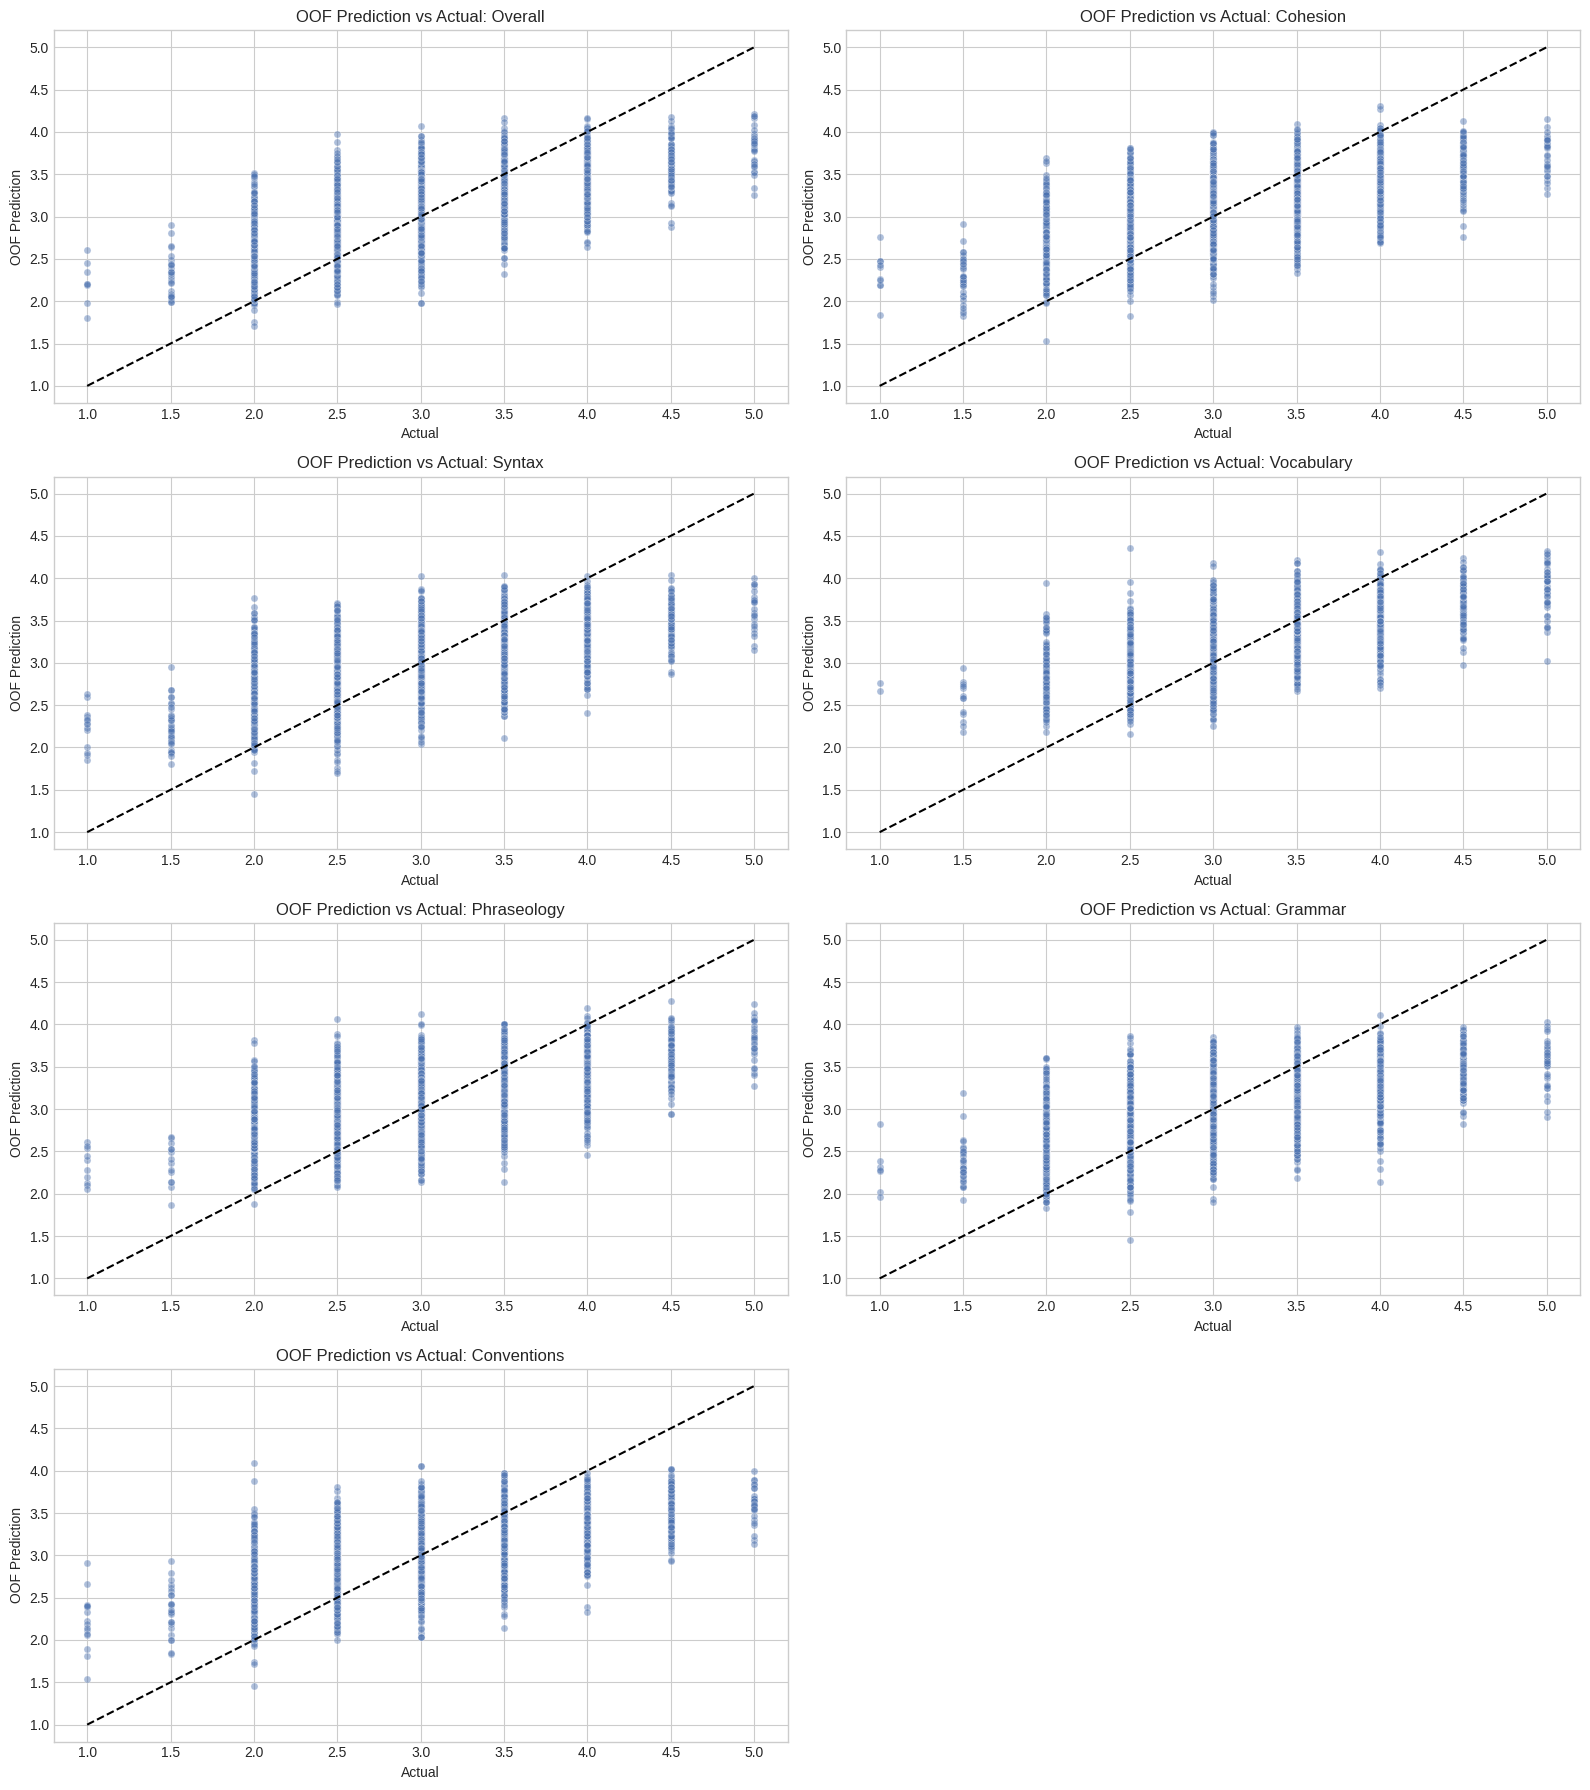

In [19]:
# Visualize blended out-of-fold predictions against actual values
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    sns.scatterplot(x=y[target], y=best_oof[:, idx], ax=axes[idx], s=26, alpha=0.45)
    min_val = min(y[target].min(), best_oof[:, idx].min())
    max_val = max(y[target].max(), best_oof[:, idx].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
    axes[idx].set_title(f'OOF Prediction vs Actual: {target}')
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('OOF Prediction')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions,mean_importance
word_svd_11,301.30000,277.40000,305.60000,260.10000,299.00000,304.20000,258.70000,286.61429
word_svd_14,292.50000,240.80000,273.60000,234.50000,292.10000,280.40000,269.00000,268.98571
word_svd_64,214.90000,177.70000,174.80000,184.50000,212.50000,184.50000,190.00000,191.27143
char_svd_24,210.40000,179.10000,173.60000,207.10000,205.10000,183.00000,170.30000,189.80000
char_svd_0,186.90000,202.30000,161.10000,150.50000,156.90000,133.90000,269.50000,180.15714
unique_word_count,220.60000,179.30000,160.40000,264.30000,199.10000,113.40000,117.30000,179.20000
char_svd_8,180.40000,173.10000,183.60000,191.80000,155.30000,137.70000,194.00000,173.70000
word_svd_12,179.20000,150.30000,139.60000,148.40000,200.00000,177.60000,181.20000,168.04286
word_svd_13,175.10000,139.90000,170.50000,157.00000,181.60000,194.50000,153.40000,167.42857
punctuation_density,183.50000,170.20000,168.10000,158.20000,157.80000,130.30000,175.70000,163.40000


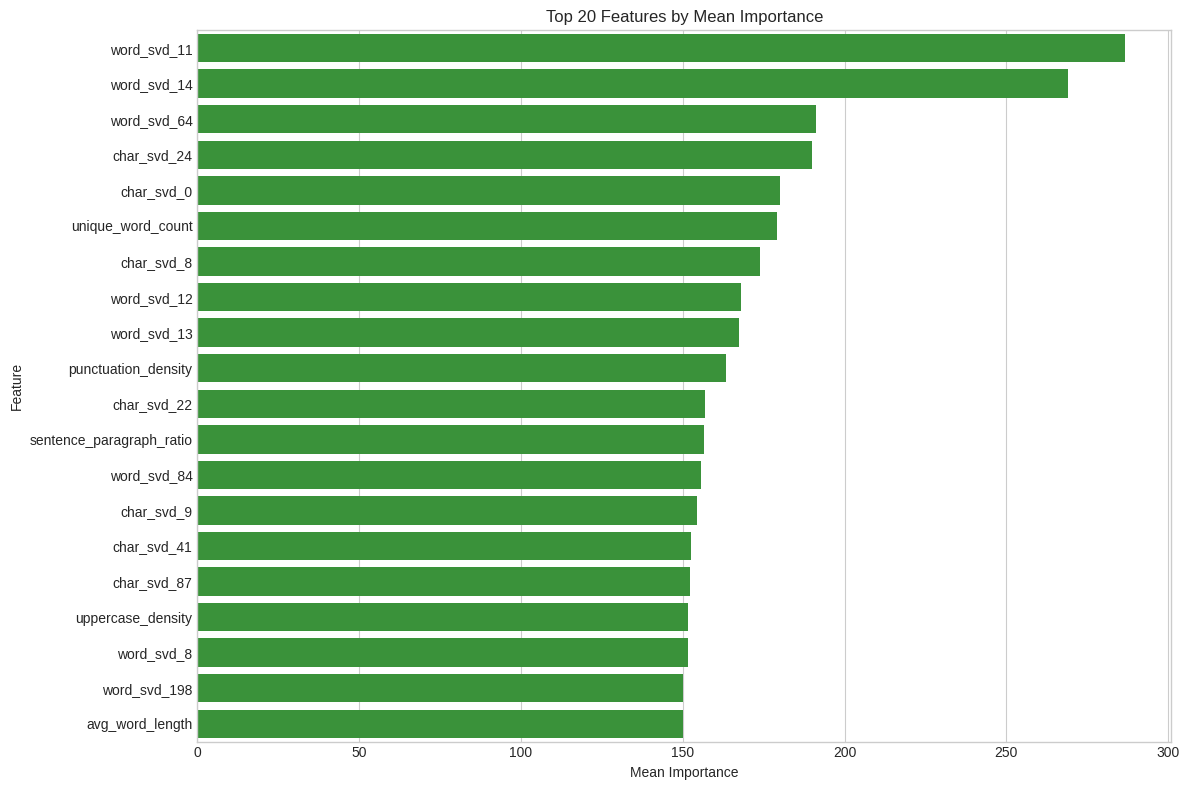

In [20]:
# Rank the most influential features across targets
importance_df = pd.DataFrame(importance_store, index=X_train.columns)
importance_df['mean_importance'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('mean_importance', ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20).reset_index(), x='mean_importance', y='index', color='#2ca02c')
plt.title('Top 20 Features by Mean Importance')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

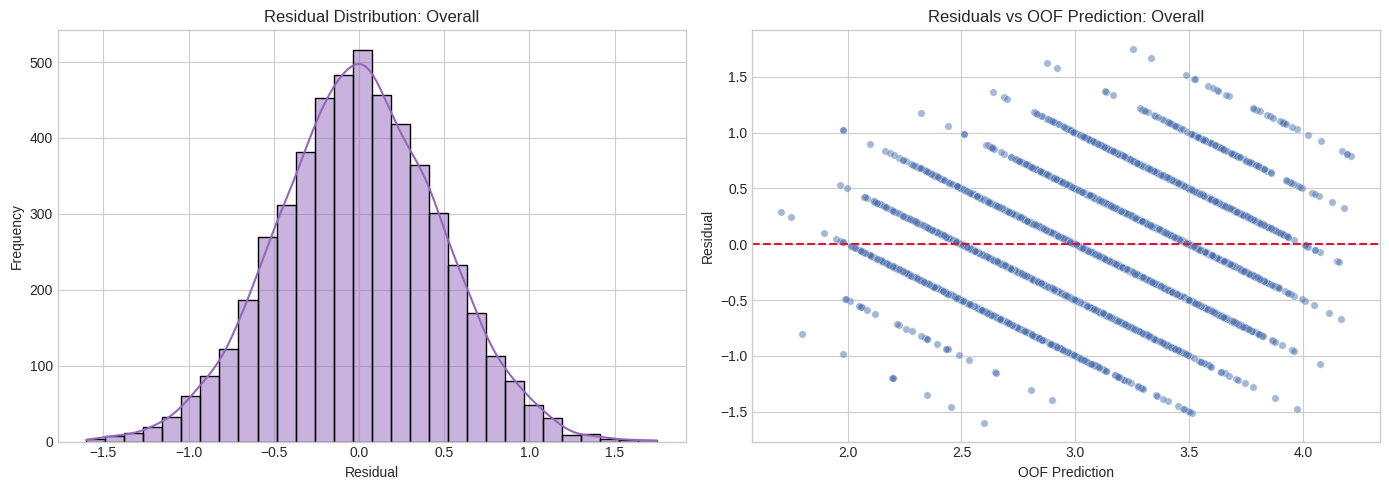

In [21]:
# Inspect residual structure for the blended Overall target
residuals = y['Overall'].values - best_oof[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, bins=30, kde=True, ax=axes[0], color='#9467bd')
axes[0].set_title('Residual Distribution: Overall')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')

sns.scatterplot(x=best_oof[:, 0], y=residuals, ax=axes[1], s=28, alpha=0.5)
axes[1].axhline(0, color='crimson', linestyle='--')
axes[1].set_title('Residuals vs OOF Prediction: Overall')
axes[1].set_xlabel('OOF Prediction')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

## 8. Submission

The final ensemble predictions are aggregated, clipped to the valid target range, and saved for competition submission.

In [22]:
# Create the final submission file from the blended prediction
submission = sample_submission.copy()
submission[ID_COL] = test_ids.values
submission[TARGET_COLS] = best_test
display(submission.head())
submission.to_csv(OUTPUT_PATH, index=False)
print(f'Submission saved to: {OUTPUT_PATH.resolve()}')

,id,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions
0,0EC7D67618F4,2.99160,3.16661,2.95882,3.08331,2.91889,2.63470,3.04721
1,64DBE55E9EA8,2.66802,2.65553,2.56487,2.94399,2.82688,2.76022,2.55287
2,3B2DADB10DCA,3.18645,3.25692,3.13645,3.36919,3.11877,2.87637,3.21846
3,746A0BFABA84,3.60100,3.48559,3.59129,3.53317,3.60204,3.44508,3.53202
4,242632EC61DF,3.76388,3.72895,3.65974,3.90354,3.72661,3.51927,3.77203


Submission saved to: /kaggle/working/submission.csv


## 9. Conclusion

- The notebook combines structured essay features with reduced word and character TF-IDF representations.
- The modeling section compares two target-wise LightGBM configurations and one Ridge baseline under shared folds.
- Out-of-fold blend search is used to select a compact weighted ensemble.
- The notebook writes `submission.csv` in the required competition format.

## 10. References

- Nguyen Khac Trung Kien. *English Scoring - Corrected Ver.* https://kaggle.com/competitions/english-scoring-corrected-ver
- Pedregosa, F. et al. *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 2011.
- Ke, G. et al. *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* NeurIPS 2017.